## 1. Import Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import pairwise_distances
from sklearn.utils import shuffle

import warnings
warnings.filterwarnings('ignore')

# Consistent plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('All libraries imported successfully ✅')

All libraries imported successfully ✅


In [5]:
df = pd.read_csv('spotify_tracks.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (50000, 21)
Columns: ['track_id', 'track_name', 'artist_name', 'album_name', 'release_year', 'genre', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'key', 'mode', 'time_signature']


,track_id,track_name,artist_name,album_name,release_year,genre,popularity,duration_ms,explicit,danceability,...,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,key,mode,time_signature
0,P3fAbnFbmOHnKYaXRvj7uf,One Dance (Acoustic Version),Alex Rodriguez,The Night Album,2024,metal,14,189042,True,0.427723,...,-4.702460,0.050635,0.239506,0.181395,0.133053,0.431384,141.048735,6,0,4
1,M2wleOV911xCZkwPRQeNHp,Forever Song (Remix),Desert Wind,Burning Soul,2019,rock,11,186805,True,0.448634,...,-7.110031,0.000000,0.044463,0.097818,0.435949,0.559135,131.833287,0,1,5
2,4JSnE2NiiUHUAKw9iEU1jj,Last Mountain,The Midnight,The Night Album,2022,k-pop,23,121814,False,0.707923,...,-7.305120,0.144091,0.118380,0.000000,0.262254,0.516873,127.132954,2,1,5
3,2UVvsjaSS8VFgM0Fmxk754,Falling Star (Live),Phantom Keys,Phantom's Greatest Hits,2024,latin,34,216049,False,0.846237,...,-9.527256,0.006668,0.272844,0.000000,0.045332,0.667911,93.041715,0,1,6
4,EeVVhDIq2AnHTmt9OBGhnu,Rising Moon (feat. someone),Desert Wind,Rising Soul,2010,latin,31,156170,False,0.943720,...,-9.017653,0.057632,0.219752,0.098044,0.132083,0.772151,93.404975,7,1,4


## 3. Exploratory Data Analysis (EDA)

In [6]:
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Basic Stats ===')
df.describe().round(3)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          50000 non-null  object 
 1   track_name        50000 non-null  object 
 2   artist_name       50000 non-null  object 
 3   album_name        50000 non-null  object 
 4   release_year      50000 non-null  int64  
 5   genre             50000 non-null  object 
 6   popularity        50000 non-null  int64  
 7   duration_ms       50000 non-null  int64  
 8   explicit          50000 non-null  bool   
 9   danceability      50000 non-null  float64
 10  energy            50000 non-null  float64
 11  loudness          50000 non-null  float64
 12  speechiness       50000 non-null  float64
 13  acousticness      50000 non-null  float64
 14  instrumentalness  50000 non-null  float64
 15  liveness          50000 non-null  float64
 16  valence           5

,release_year,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,key,mode,time_signature
count,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000
mean,2015.853,23.600,209976.955,0.627,0.659,-7.439,0.076,0.276,0.155,0.181,0.581,116.258,5.477,0.620,4.043
std,6.178,17.913,44881.859,0.208,0.213,4.306,0.065,0.258,0.235,0.097,0.184,23.706,3.599,0.485,0.514
min,2000.000,-5.000,90000.000,0.000,0.000,-27.796,0.000,0.000,0.000,0.000,0.000,50.000,0.000,0.000,3.000
25%,2012.000,11.000,179812.250,0.489,0.540,-9.803,0.031,0.075,0.000,0.112,0.458,100.238,2.000,0.000,4.000
50%,2017.000,19.000,209886.500,0.651,0.683,-6.907,0.063,0.199,0.065,0.180,0.581,115.326,5.000,1.000,4.000
75%,2021.000,31.000,240023.750,0.783,0.812,-4.426,0.099,0.413,0.168,0.248,0.708,130.456,9.000,1.000,4.000
max,2024.000,100.000,403583.000,1.000,1.000,0.000,0.368,1.000,1.000,0.582,1.000,220.000,11.000,1.000,7.000


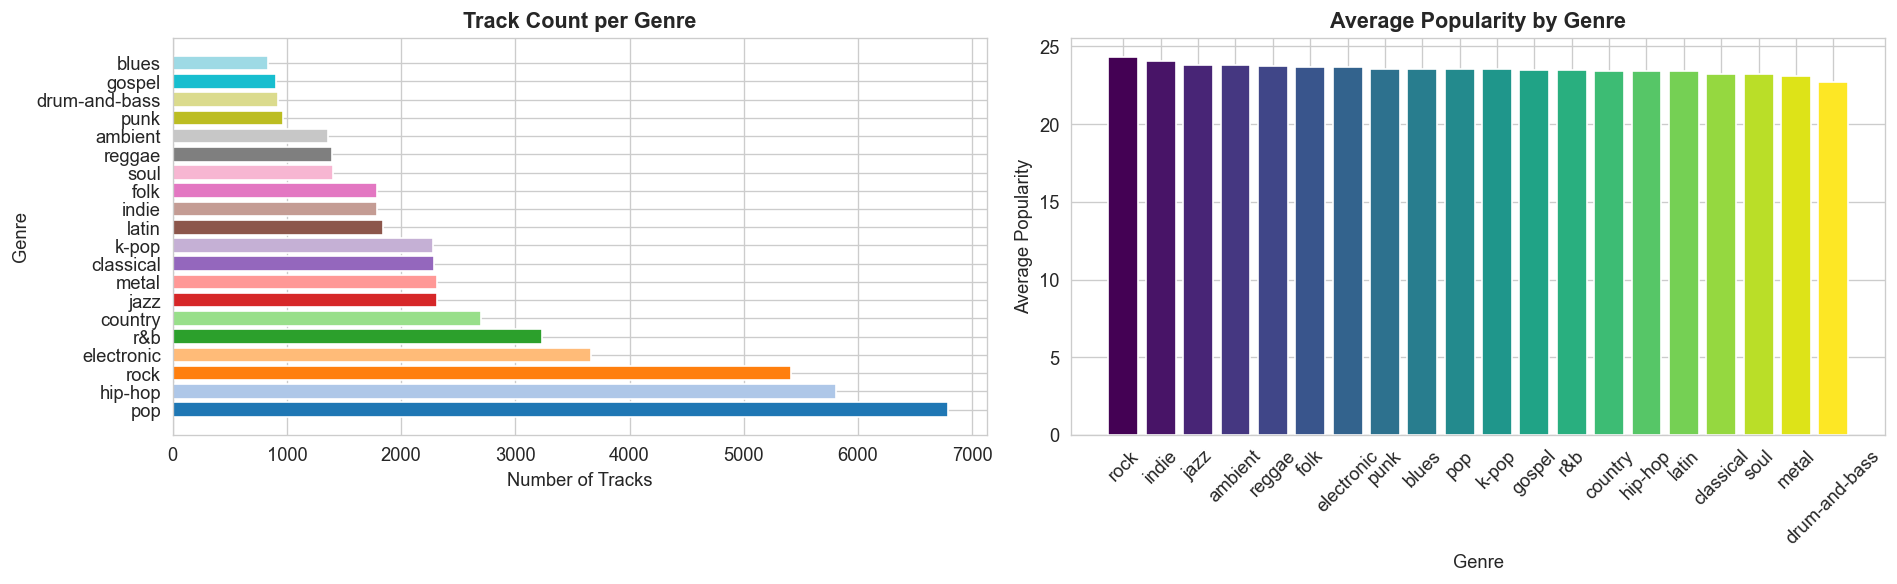

In [7]:
# Genre distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Count plot
genre_counts = df['genre'].value_counts()
axes[0].barh(genre_counts.index, genre_counts.values,
             color=plt.cm.tab20(np.linspace(0, 1, len(genre_counts))))
axes[0].set_title('Track Count per Genre', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Tracks')
axes[0].set_ylabel('Genre')

# Popularity by genre
genre_pop = df.groupby('genre')['popularity'].mean().sort_values(ascending=False)
axes[1].bar(genre_pop.index, genre_pop.values,
            color=plt.cm.viridis(np.linspace(0, 1, len(genre_pop))))
axes[1].set_title('Average Popularity by Genre', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Average Popularity')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

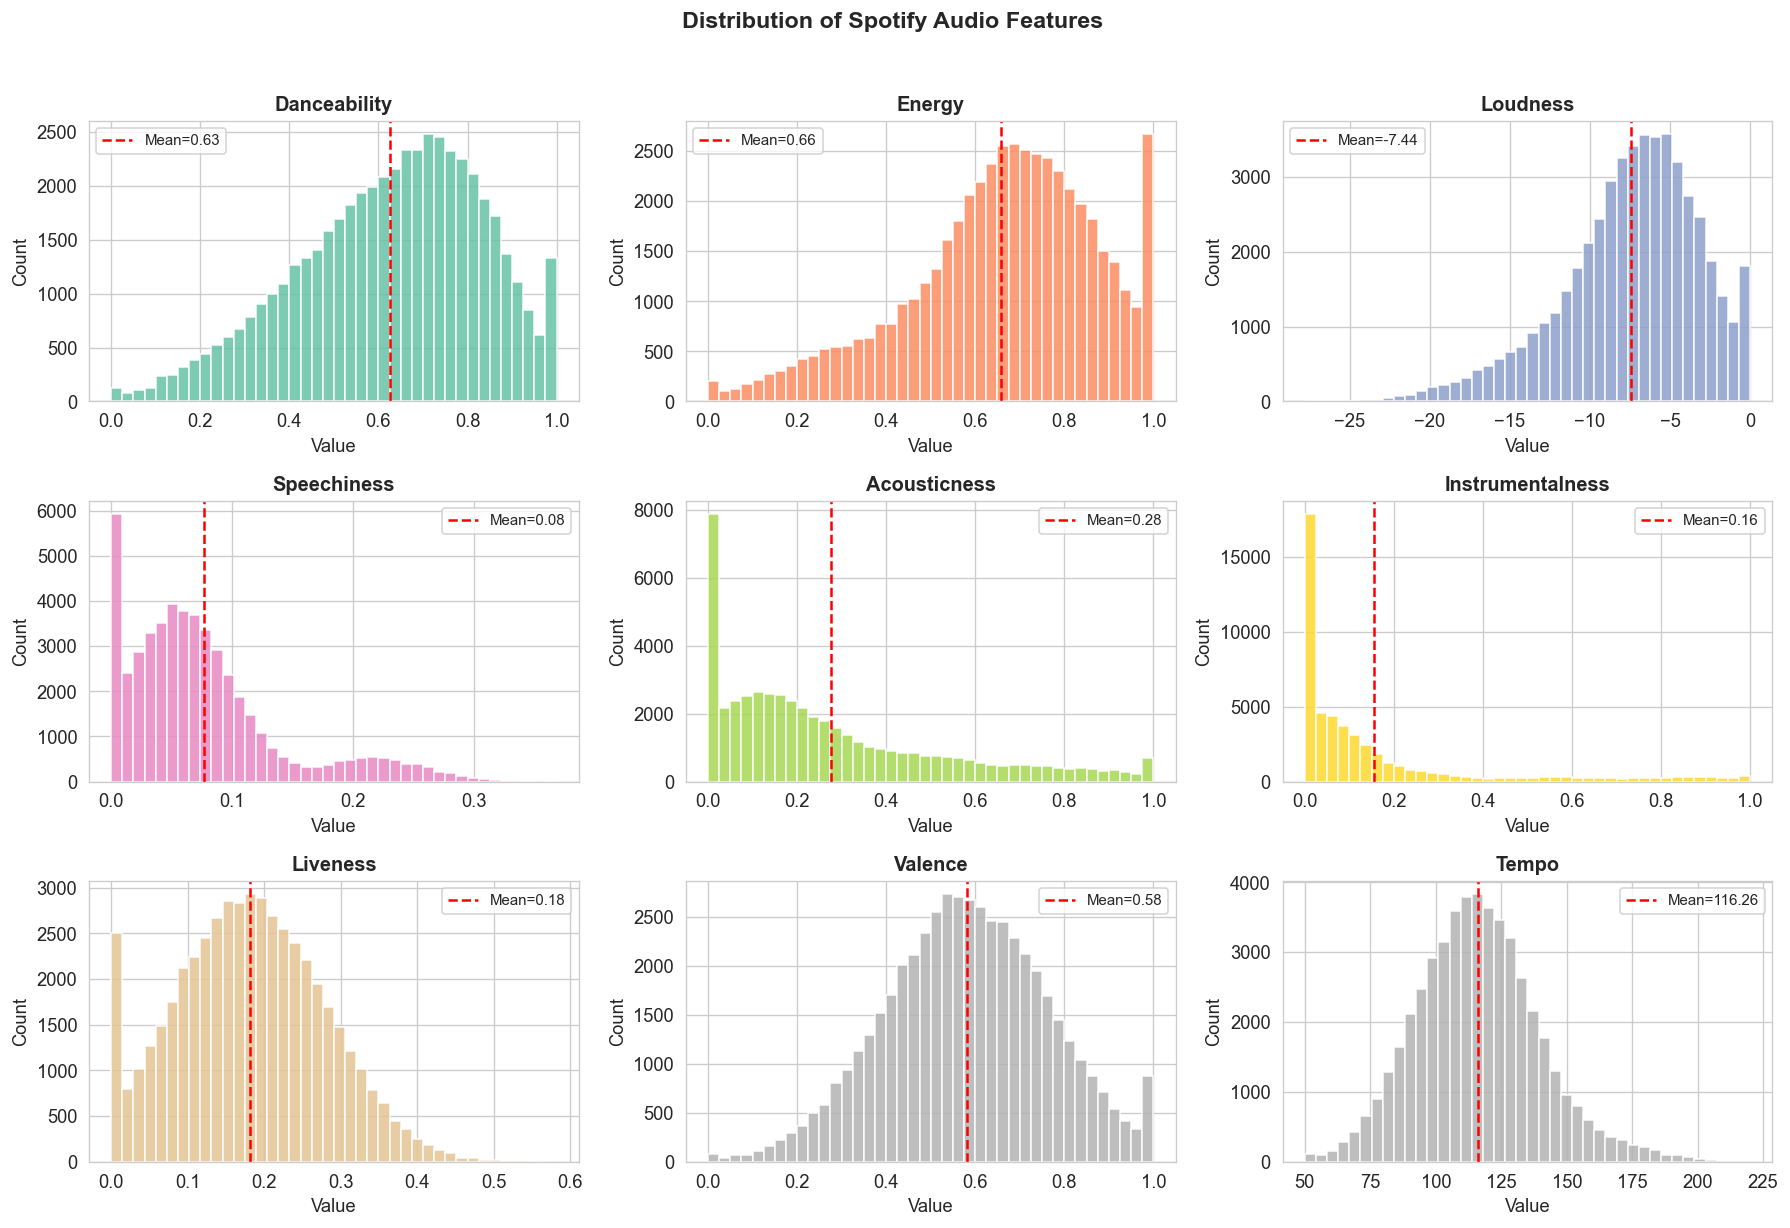

In [8]:
# Distribution of all audio features
audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

colors = plt.cm.Set2(np.linspace(0, 1, len(audio_features)))

for i, (feat, color) in enumerate(zip(audio_features, colors)):
    axes[i].hist(df[feat], bins=40, color=color, edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{feat.capitalize()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    mean_val = df[feat].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean={mean_val:.2f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribution of Spotify Audio Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

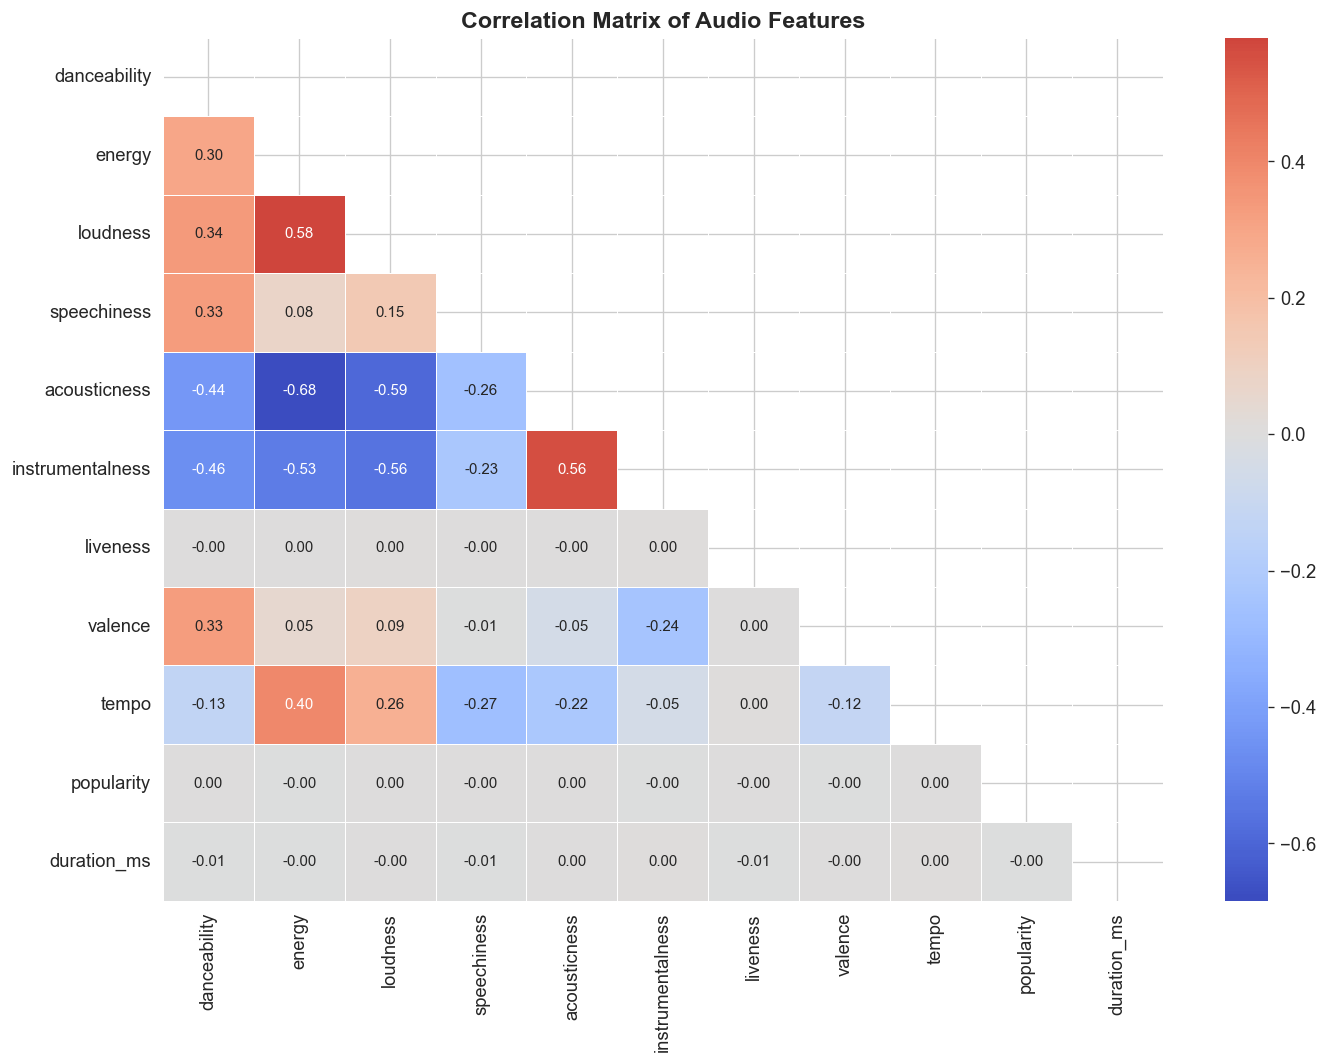

In [9]:
# Correlation heatmap of audio features
corr_features = audio_features + ['popularity', 'duration_ms']
corr_matrix = df[corr_features].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 9}
)
plt.title('Correlation Matrix of Audio Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

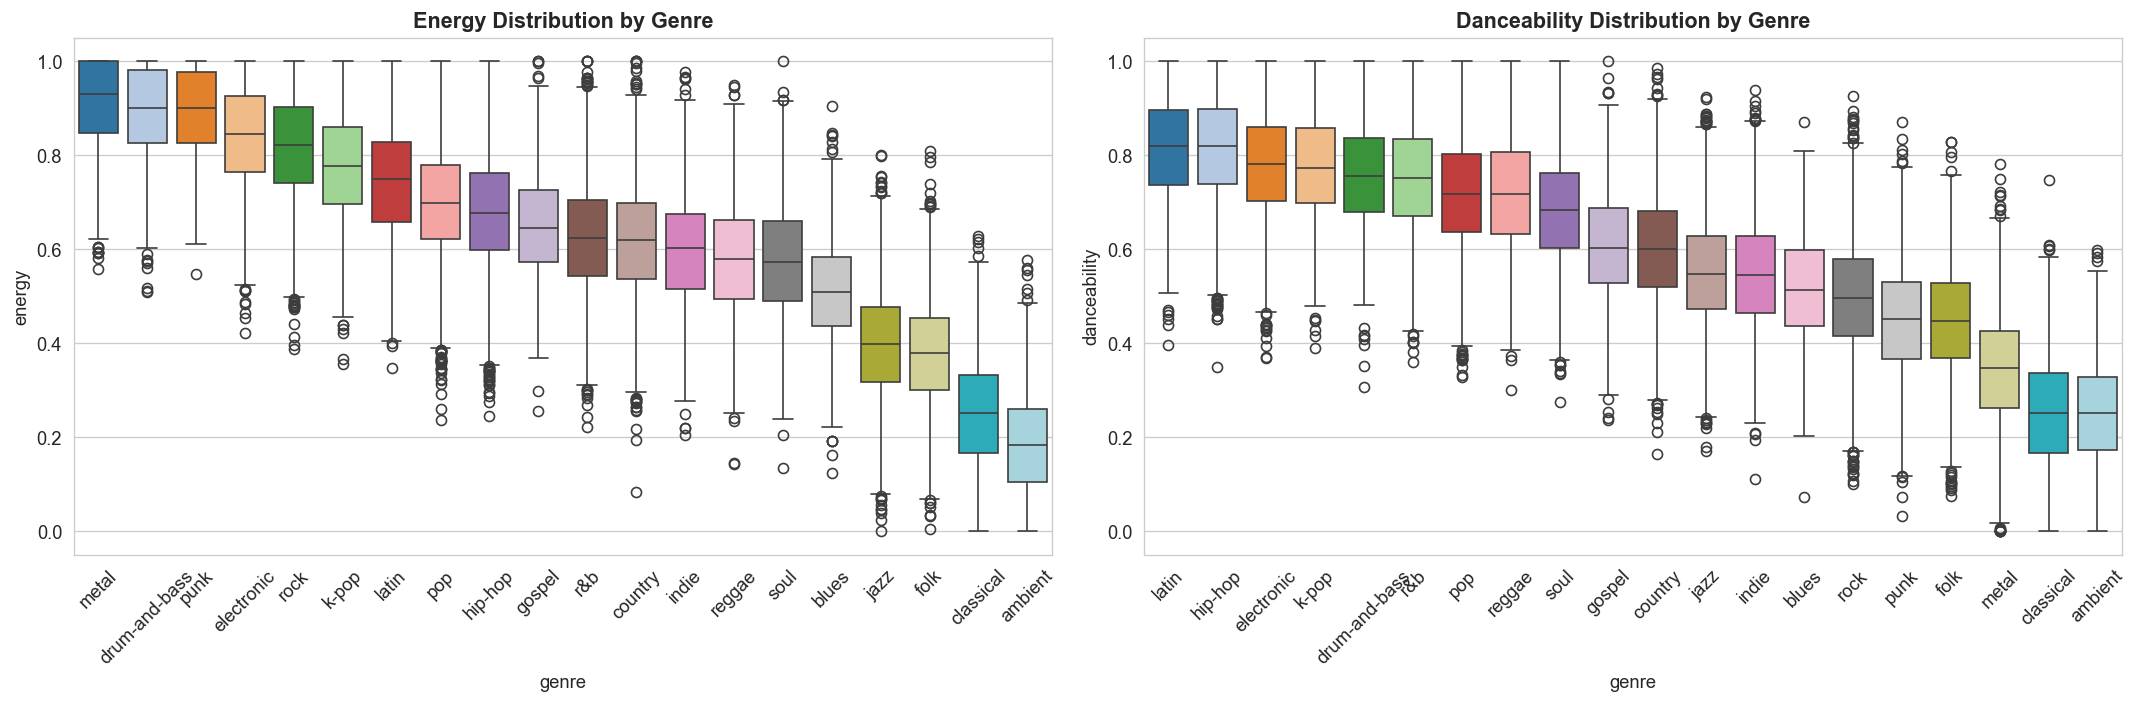

In [10]:
# Boxplots: Energy and Danceability by Genre
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

genre_order = df.groupby('genre')['energy'].median().sort_values(ascending=False).index

sns.boxplot(data=df, x='genre', y='energy', order=genre_order,
            palette='tab20', ax=axes[0])
axes[0].set_title('Energy Distribution by Genre', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

genre_order2 = df.groupby('genre')['danceability'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='genre', y='danceability', order=genre_order2,
            palette='tab20', ax=axes[1])
axes[1].set_title('Danceability Distribution by Genre', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [11]:
# Select numeric audio features for MDS
audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

# Encode genre as numeric label (for coloring)
le = LabelEncoder()
df['genre_label'] = le.fit_transform(df['genre'])
genres = le.classes_
n_genres = len(genres)
print(f'Genres ({n_genres}): {list(genres)}')

# Sample for MDS (use up to 500 points — MDS is O(n^2))
SAMPLE_SIZE = 500
df_sample = df.groupby('genre', group_keys=False).apply(
    lambda x: x.sample(min(len(x), SAMPLE_SIZE // n_genres), random_state=42)
).reset_index(drop=True)

print(f'\nSample size: {len(df_sample)} tracks across {n_genres} genres')
print(df_sample['genre'].value_counts())

Genres (20): ['ambient', 'blues', 'classical', 'country', 'drum-and-bass', 'electronic', 'folk', 'gospel', 'hip-hop', 'indie', 'jazz', 'k-pop', 'latin', 'metal', 'pop', 'punk', 'r&b', 'reggae', 'rock', 'soul']

Sample size: 500 tracks across 20 genres
genre
ambient          25
blues            25
classical        25
country          25
drum-and-bass    25
electronic       25
folk             25
gospel           25
hip-hop          25
indie            25
jazz             25
k-pop            25
latin            25
metal            25
pop              25
punk             25
r&b              25
reggae           25
rock             25
soul             25
Name: count, dtype: int64


In [12]:
# Standardize features
X = df_sample[audio_features].values
y_genre = df_sample['genre_label'].values
y_popularity = df_sample['popularity'].values
genre_names = df_sample['genre'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature matrix shape:', X_scaled.shape)
print('Mean after scaling (should be ~0):', X_scaled.mean(axis=0).round(4))
print('Std after scaling (should be ~1): ', X_scaled.std(axis=0).round(4))

Feature matrix shape: (500, 9)
Mean after scaling (should be ~0): [ 0. -0. -0.  0. -0.  0.  0.  0.  0.]
Std after scaling (should be ~1):  [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 5. Before MDS — Original Feature Space Visualizations

Before applying MDS, let's look at how the data looks in 2D and 3D using **raw (standardized) features** directly. This gives us the "before" picture.

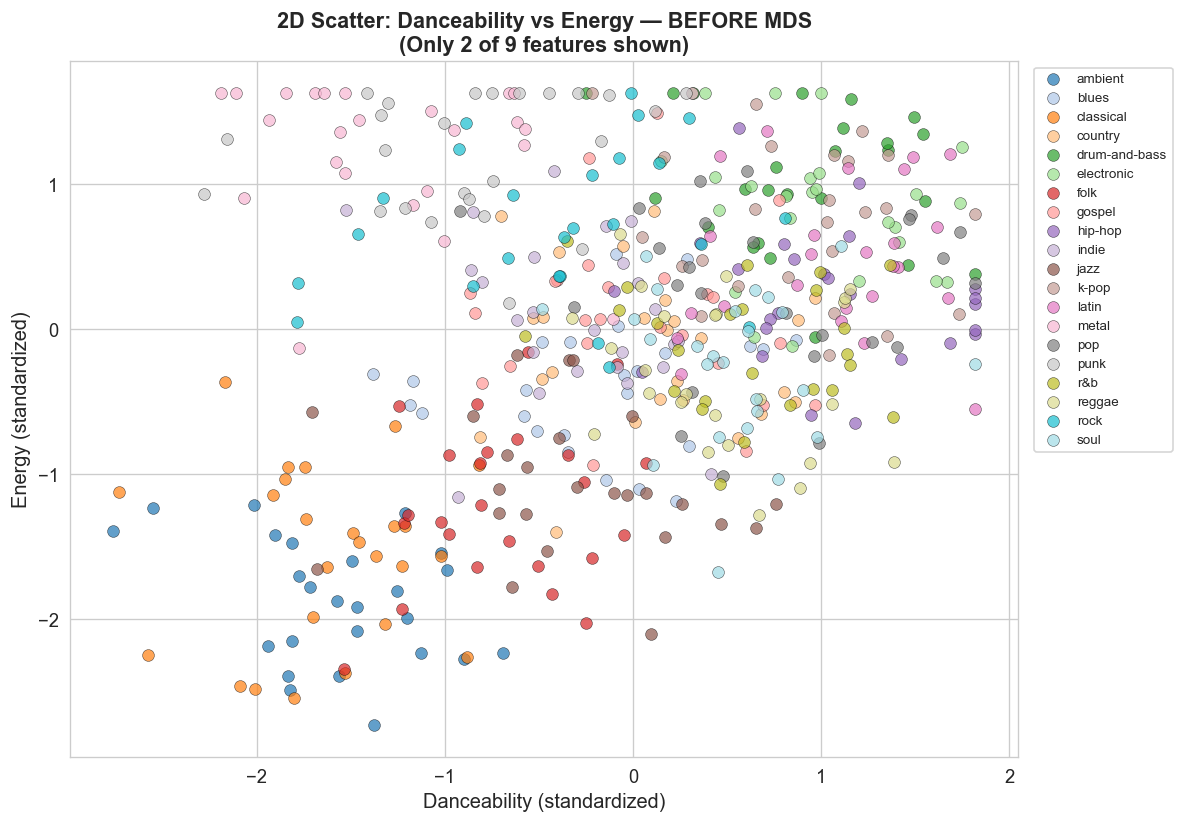

In [13]:
# 2D Scatter: Danceability vs Energy (colored by genre)
cmap = plt.cm.get_cmap('tab20', n_genres)

plt.figure(figsize=(10, 7))
for i, genre in enumerate(genres):
    mask = genre_names == genre
    plt.scatter(
        X_scaled[mask, 0],   # danceability (standardized)
        X_scaled[mask, 1],   # energy (standardized)
        color=cmap(i), label=genre, alpha=0.7, edgecolors='k', linewidths=0.3, s=50
    )

plt.xlabel('Danceability (standardized)', fontsize=12)
plt.ylabel('Energy (standardized)', fontsize=12)
plt.title('2D Scatter: Danceability vs Energy — BEFORE MDS\n(Only 2 of 9 features shown)', fontsize=13, fontweight='bold')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, ncol=1)
plt.tight_layout()
plt.show()

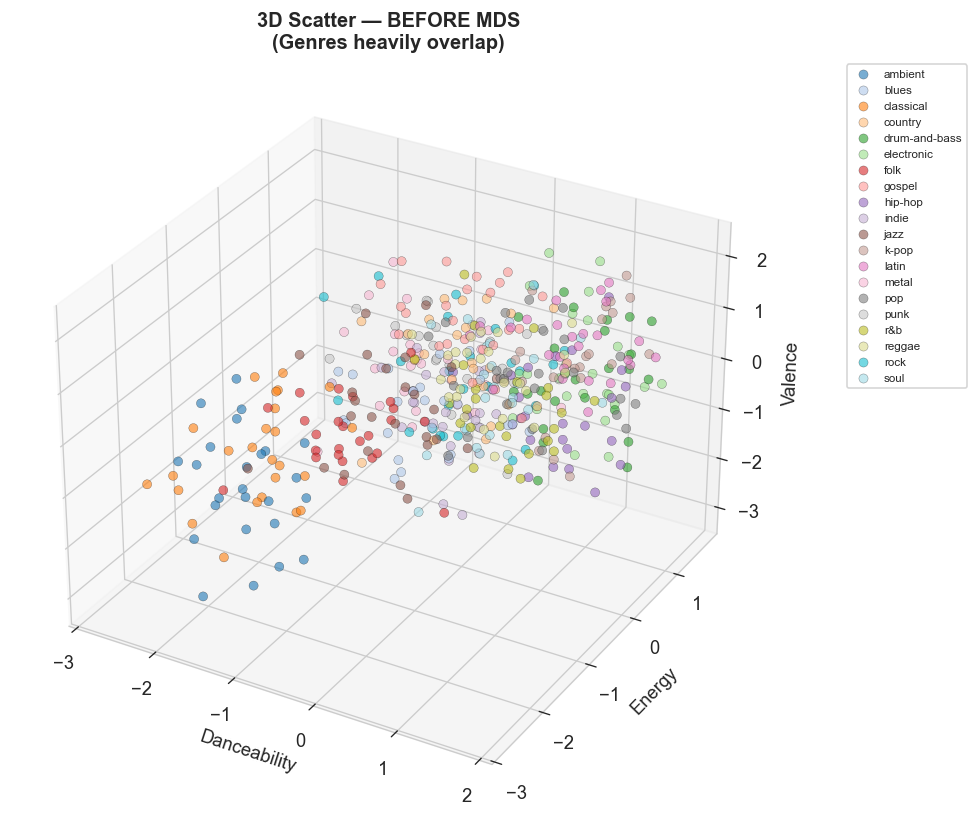

In [14]:
# 3D Scatter: Danceability vs Energy vs Valence — BEFORE MDS
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for i, genre in enumerate(genres):
    mask = genre_names == genre
    ax.scatter(
        X_scaled[mask, 0],
        X_scaled[mask, 1],
        X_scaled[mask, 7],   # valence
        color=cmap(i), label=genre, alpha=0.6, edgecolors='k', linewidths=0.2, s=30
    )

ax.set_xlabel('Danceability')
ax.set_ylabel('Energy')
ax.set_zlabel('Valence')
ax.set_title('3D Scatter — BEFORE MDS\n(Genres heavily overlap)', fontsize=12, fontweight='bold')
ax.legend(bbox_to_anchor=(1.1, 1), loc='upper left', fontsize=7, ncol=1)
plt.tight_layout()
plt.show()

## 6. Apply MDS

We apply MDS in **2D** and **3D** using the full 9-dimensional standardized feature space.

In [15]:
# MDS in 2D
print('Fitting MDS (2D)... this may take a moment ⏳')
mds_2d = MDS(n_components=2, metric=True, dissimilarity='euclidean',
             n_init=4, random_state=42, n_jobs=-1)
X_mds_2d = mds_2d.fit_transform(X_scaled)

print(f'MDS 2D complete ✅')
print(f'Stress (goodness of fit — lower is better): {mds_2d.stress_:.2f}')
print(f'Output shape: {X_mds_2d.shape}')

Fitting MDS (2D)... this may take a moment ⏳
MDS 2D complete ✅
Stress (goodness of fit — lower is better): 125940.86
Output shape: (500, 2)


In [16]:
# MDS in 3D
print('Fitting MDS (3D)... ⏳')
mds_3d = MDS(n_components=3, metric=True, dissimilarity='euclidean',
             n_init=4, random_state=42, n_jobs=-1)
X_mds_3d = mds_3d.fit_transform(X_scaled)

print(f'MDS 3D complete ✅')
print(f'Stress (3D): {mds_3d.stress_:.2f}')
print(f'Output shape: {X_mds_3d.shape}')

Fitting MDS (3D)... ⏳
MDS 3D complete ✅
Stress (3D): 55905.96
Output shape: (500, 3)


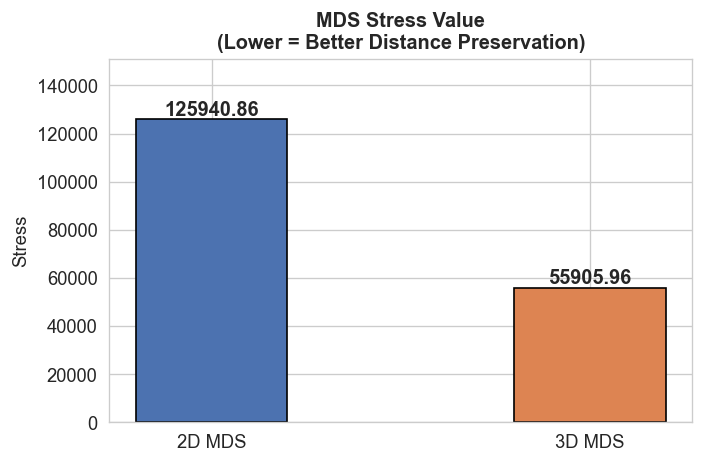


Stress Interpretation:
  < 0.05  → Excellent
  0.05–0.10 → Good
  0.10–0.20 → Fair
  > 0.20  → Poor


In [17]:
# Stress comparison bar chart
dims = ['2D MDS', '3D MDS']
stresses = [mds_2d.stress_, mds_3d.stress_]

plt.figure(figsize=(6, 4))
bars = plt.bar(dims, stresses, color=['#4C72B0', '#DD8452'], edgecolor='k', width=0.4)
for bar, val in zip(bars, stresses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.title('MDS Stress Value\n(Lower = Better Distance Preservation)', fontsize=12, fontweight='bold')
plt.ylabel('Stress')
plt.ylim(0, max(stresses) * 1.2)
plt.tight_layout()
plt.show()

print('\nStress Interpretation:')
print('  < 0.05  → Excellent')
print('  0.05–0.10 → Good')
print('  0.10–0.20 → Fair')
print('  > 0.20  → Poor')

## 7. After MDS — Visualizations

Now we visualize the **MDS-transformed coordinates** to see if genres form meaningful clusters.

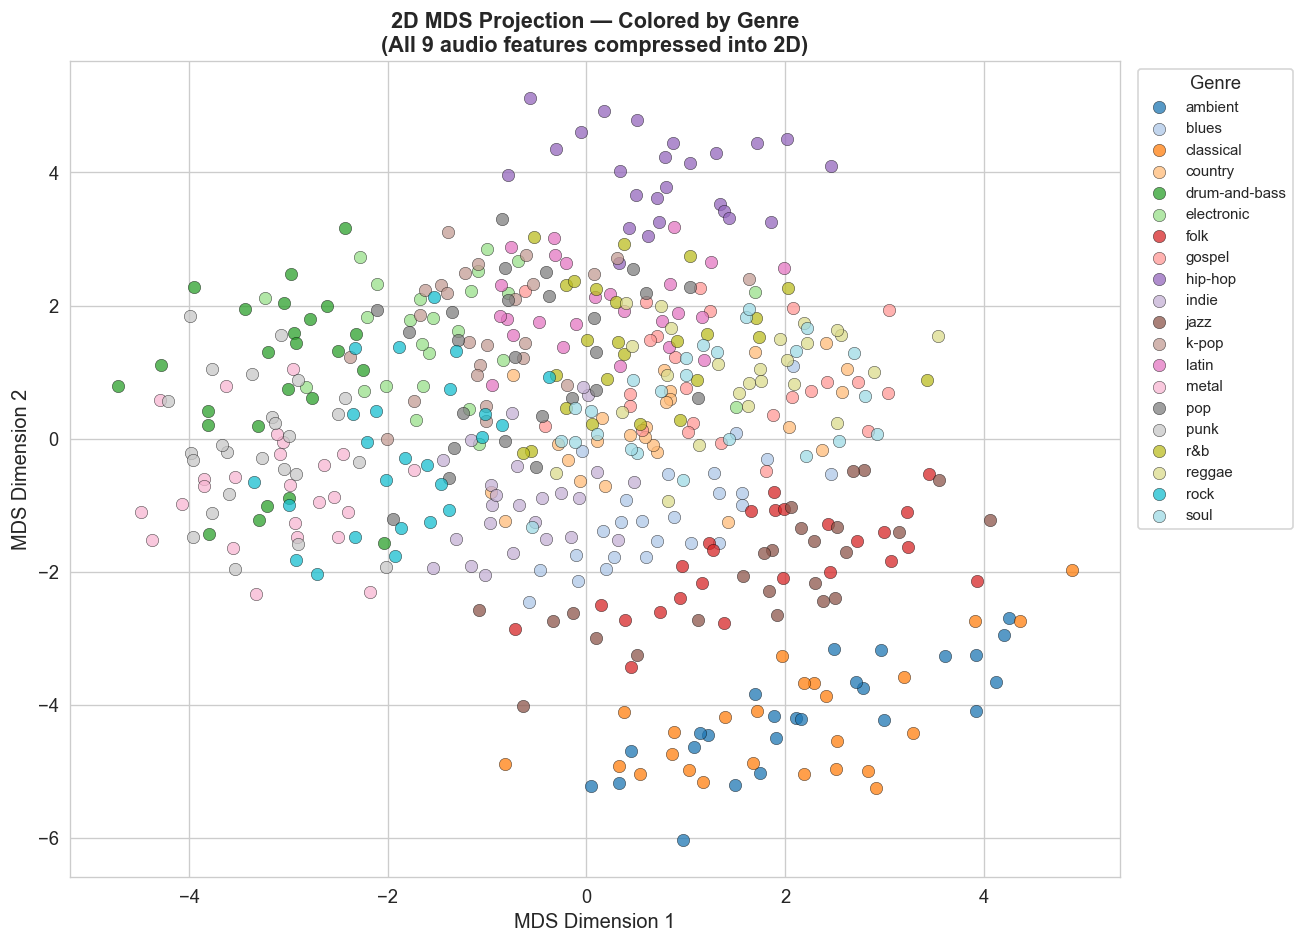

In [18]:
# MDS 2D — colored by Genre
plt.figure(figsize=(11, 8))

for i, genre in enumerate(genres):
    mask = genre_names == genre
    plt.scatter(
        X_mds_2d[mask, 0], X_mds_2d[mask, 1],
        color=cmap(i), label=genre, alpha=0.75,
        edgecolors='k', linewidths=0.3, s=55
    )

plt.xlabel('MDS Dimension 1', fontsize=12)
plt.ylabel('MDS Dimension 2', fontsize=12)
plt.title('2D MDS Projection — Colored by Genre\n(All 9 audio features compressed into 2D)', fontsize=13, fontweight='bold')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, ncol=1, title='Genre')
plt.tight_layout()
plt.show()

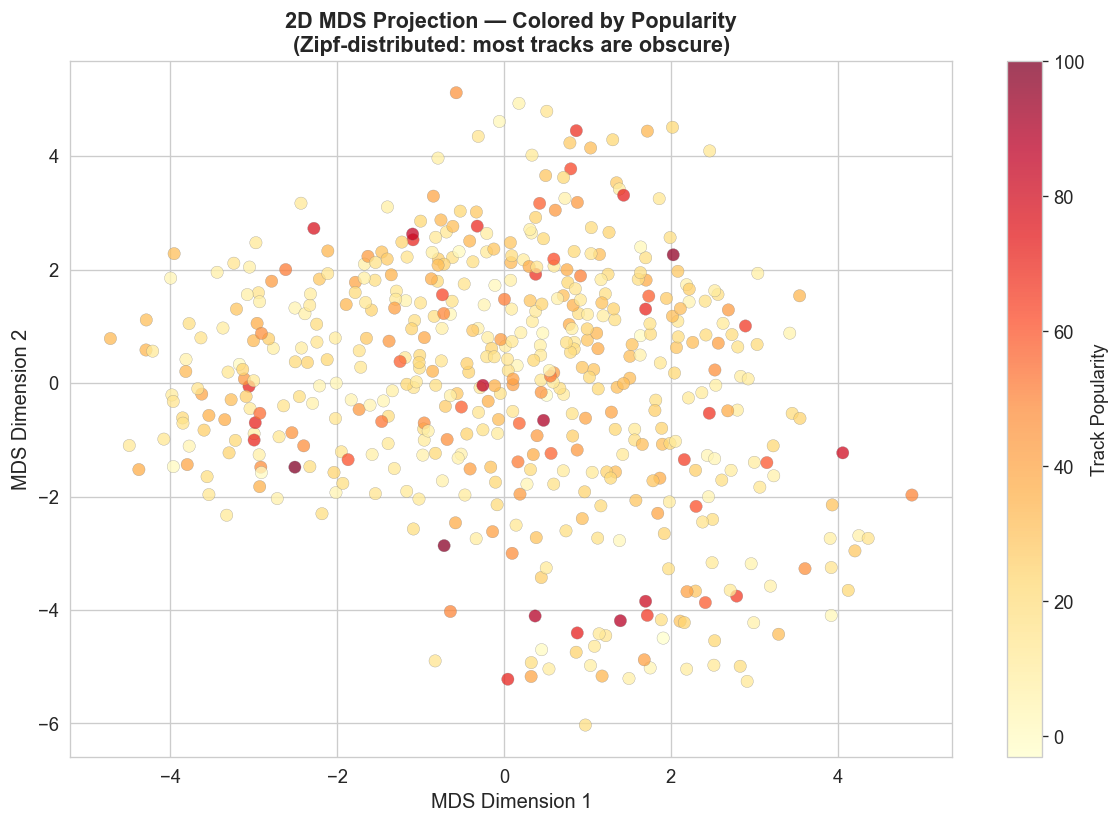

In [19]:
# MDS 2D — colored by Popularity
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_mds_2d[:, 0], X_mds_2d[:, 1],
    c=y_popularity, cmap='YlOrRd', alpha=0.75,
    edgecolors='gray', linewidths=0.2, s=55
)
plt.colorbar(scatter, label='Track Popularity')
plt.xlabel('MDS Dimension 1', fontsize=12)
plt.ylabel('MDS Dimension 2', fontsize=12)
plt.title('2D MDS Projection — Colored by Popularity\n(Zipf-distributed: most tracks are obscure)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

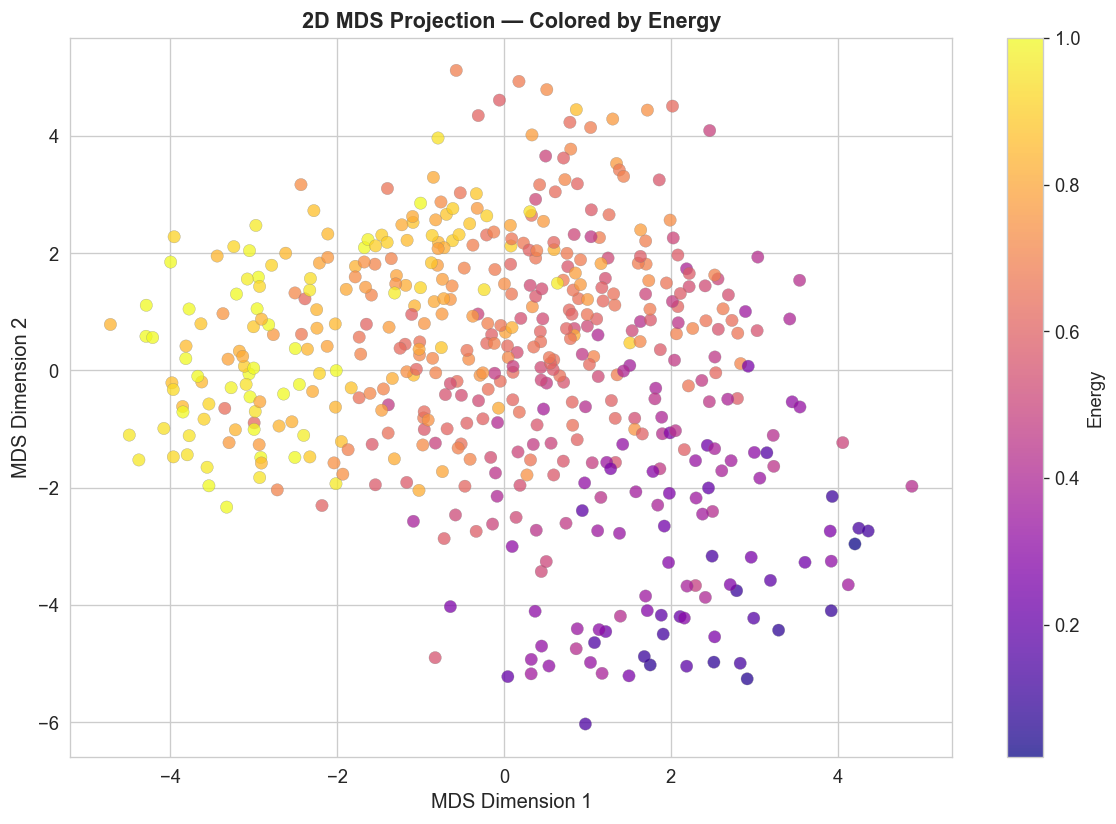

In [20]:
# MDS 2D — colored by Energy
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_mds_2d[:, 0], X_mds_2d[:, 1],
    c=df_sample['energy'].values, cmap='plasma', alpha=0.75,
    edgecolors='gray', linewidths=0.2, s=55
)
plt.colorbar(scatter, label='Energy')
plt.xlabel('MDS Dimension 1', fontsize=12)
plt.ylabel('MDS Dimension 2', fontsize=12)
plt.title('2D MDS Projection — Colored by Energy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

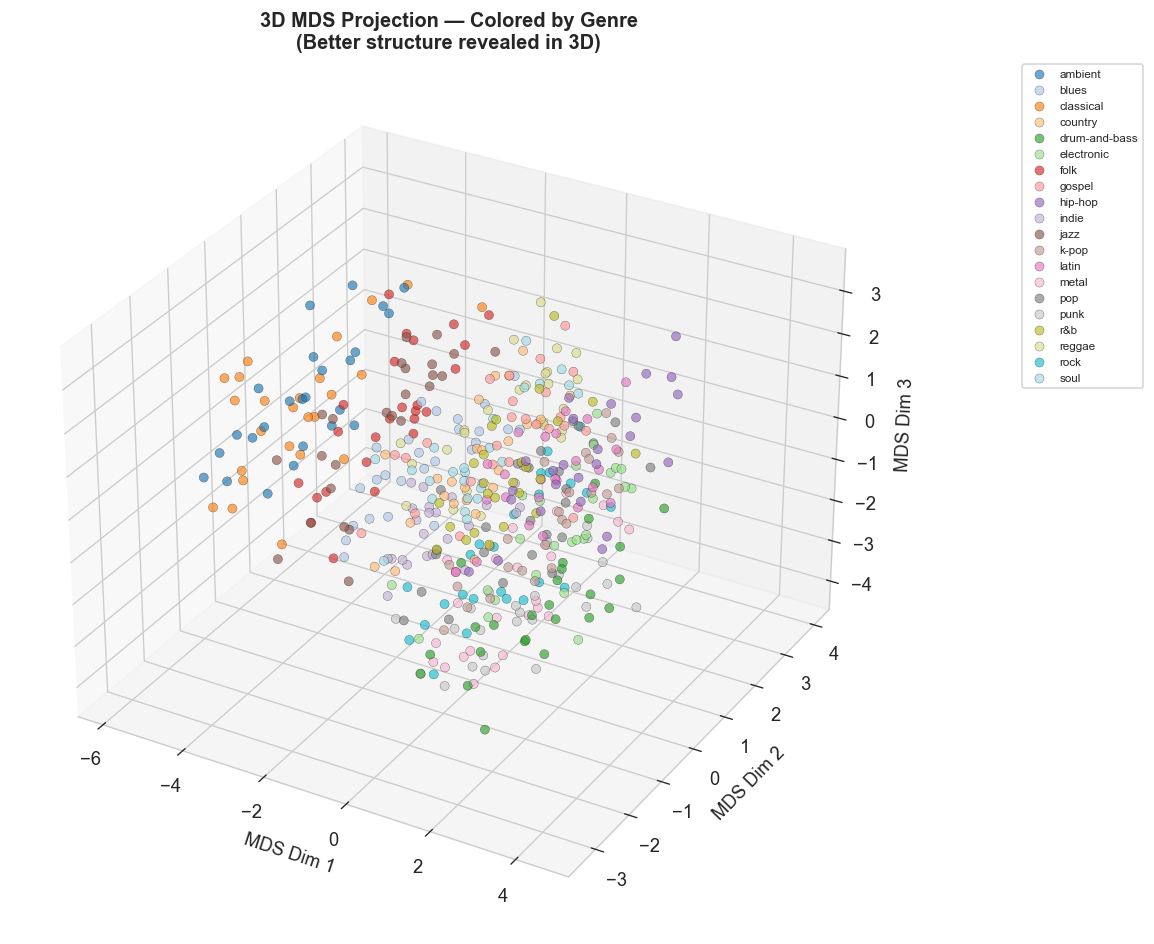

In [21]:
# MDS 3D — colored by Genre
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for i, genre in enumerate(genres):
    mask = genre_names == genre
    ax.scatter(
        X_mds_3d[mask, 0], X_mds_3d[mask, 1], X_mds_3d[mask, 2],
        color=cmap(i), label=genre, alpha=0.65,
        edgecolors='k', linewidths=0.2, s=30
    )

ax.set_xlabel('MDS Dim 1')
ax.set_ylabel('MDS Dim 2')
ax.set_zlabel('MDS Dim 3')
ax.set_title('3D MDS Projection — Colored by Genre\n(Better structure revealed in 3D)', fontsize=12, fontweight='bold')
ax.legend(bbox_to_anchor=(1.15, 1), loc='upper left', fontsize=7, ncol=1)
plt.tight_layout()
plt.show()

## 8. Side-by-Side Comparison: Before vs After MDS

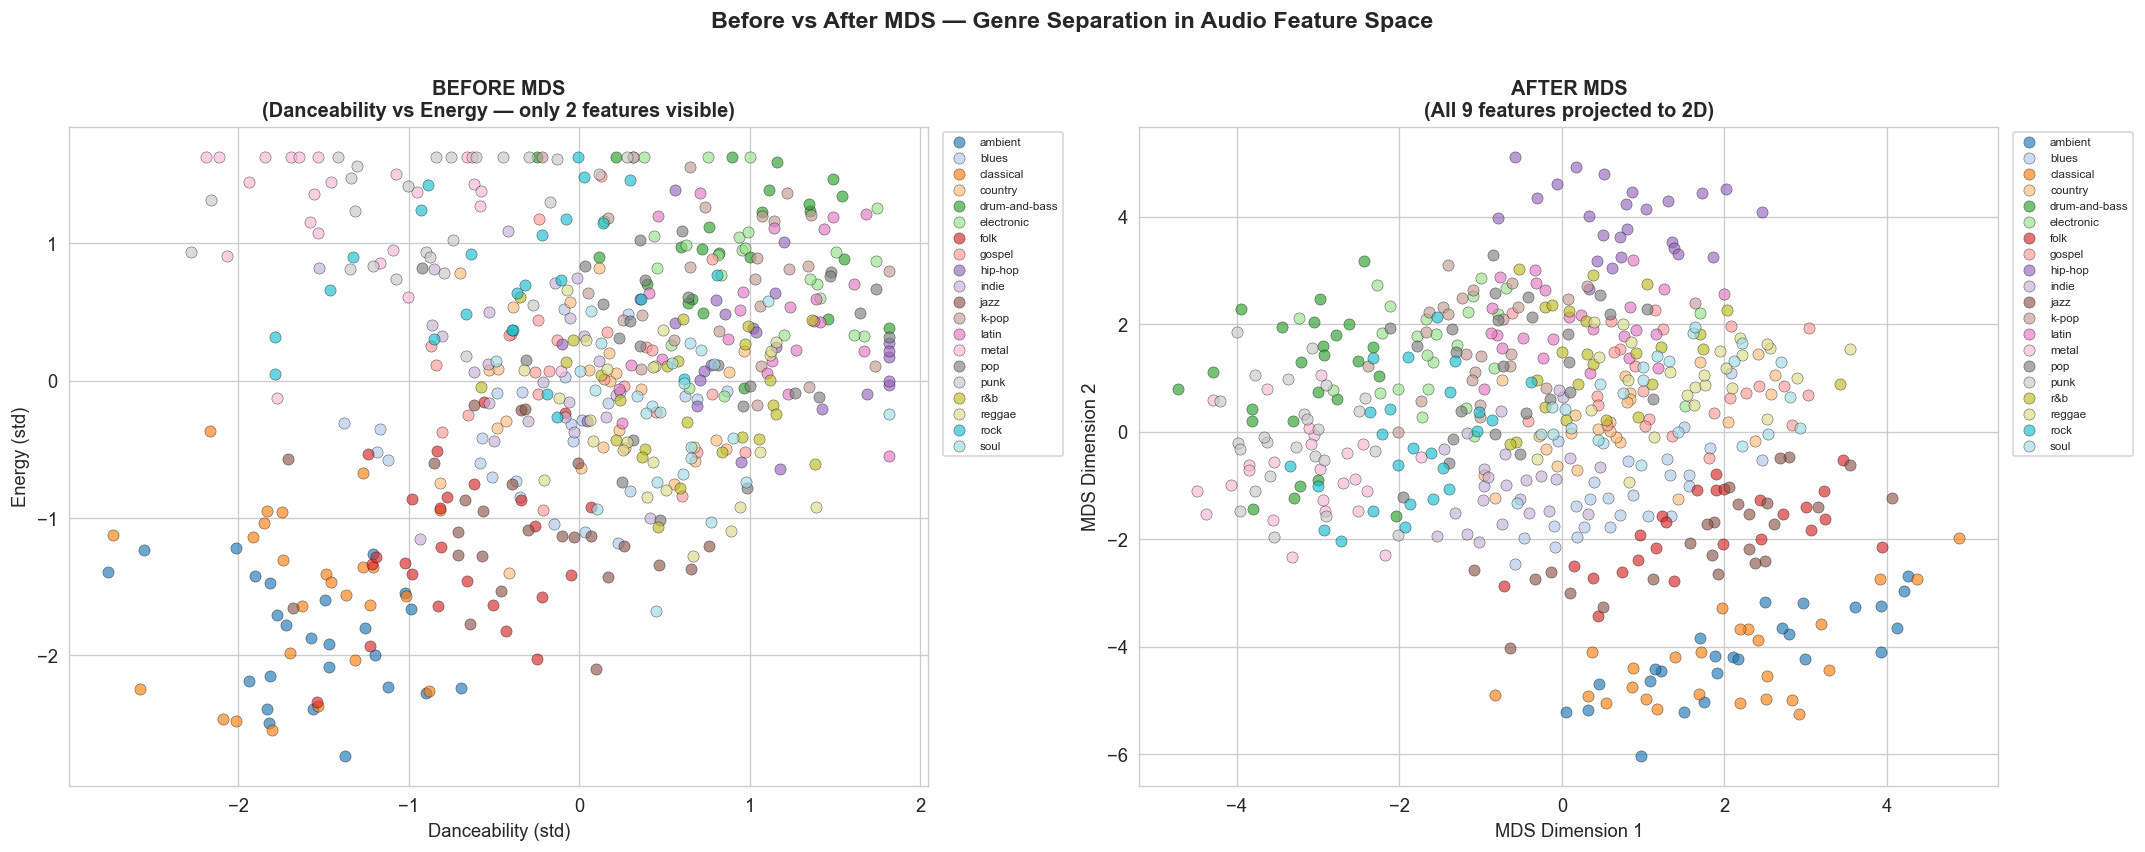

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- BEFORE MDS (raw 2 features) ---
for i, genre in enumerate(genres):
    mask = genre_names == genre
    axes[0].scatter(
        X_scaled[mask, 0], X_scaled[mask, 1],
        color=cmap(i), label=genre, alpha=0.65,
        edgecolors='k', linewidths=0.3, s=45
    )
axes[0].set_title('BEFORE MDS\n(Danceability vs Energy — only 2 features visible)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Danceability (std)')
axes[0].set_ylabel('Energy (std)')
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)

# --- AFTER MDS ---
for i, genre in enumerate(genres):
    mask = genre_names == genre
    axes[1].scatter(
        X_mds_2d[mask, 0], X_mds_2d[mask, 1],
        color=cmap(i), label=genre, alpha=0.65,
        edgecolors='k', linewidths=0.3, s=45
    )
axes[1].set_title('AFTER MDS\n(All 9 features projected to 2D)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('MDS Dimension 1')
axes[1].set_ylabel('MDS Dimension 2')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)

plt.suptitle('Before vs After MDS — Genre Separation in Audio Feature Space', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Distance Preservation Analysis

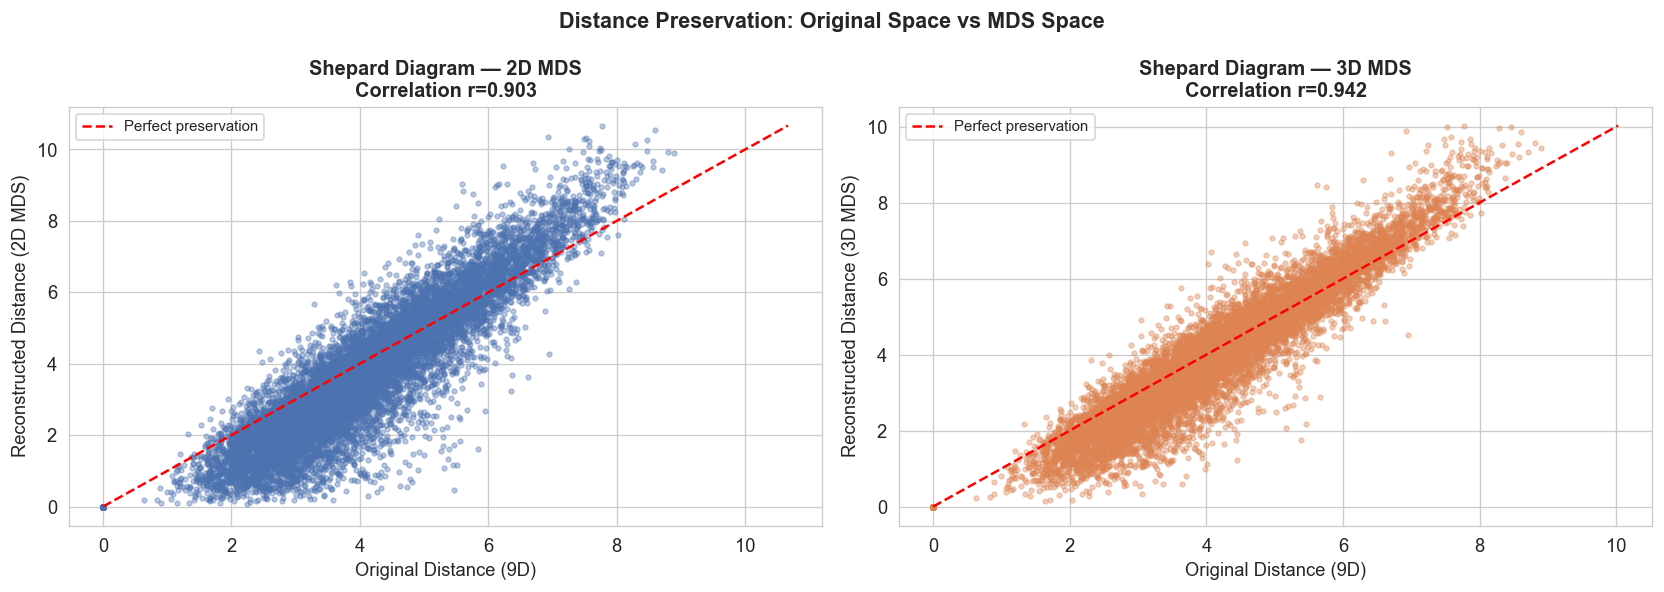

In [23]:
# Compute pairwise distances in original and MDS space
# Use a random subset of 150 points for speed
idx = np.random.choice(len(X_scaled), 150, replace=False)
orig_dist = pairwise_distances(X_scaled[idx]).ravel()
mds2_dist = pairwise_distances(X_mds_2d[idx]).ravel()
mds3_dist = pairwise_distances(X_mds_3d[idx]).ravel()

# Shepard Diagram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mds_dist, label, color in zip(
    axes,
    [mds2_dist, mds3_dist],
    ['2D MDS', '3D MDS'],
    ['#4C72B0', '#DD8452']
):
    ax.scatter(orig_dist, mds_dist, alpha=0.2, s=8, color=color)
    # Perfect preservation line
    lim = max(orig_dist.max(), mds_dist.max())
    ax.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect preservation')
    corr = np.corrcoef(orig_dist, mds_dist)[0, 1]
    ax.set_title(f'Shepard Diagram — {label}\nCorrelation r={corr:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Original Distance (9D)')
    ax.set_ylabel(f'Reconstructed Distance ({label})')
    ax.legend(fontsize=9)

plt.suptitle('Distance Preservation: Original Space vs MDS Space', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

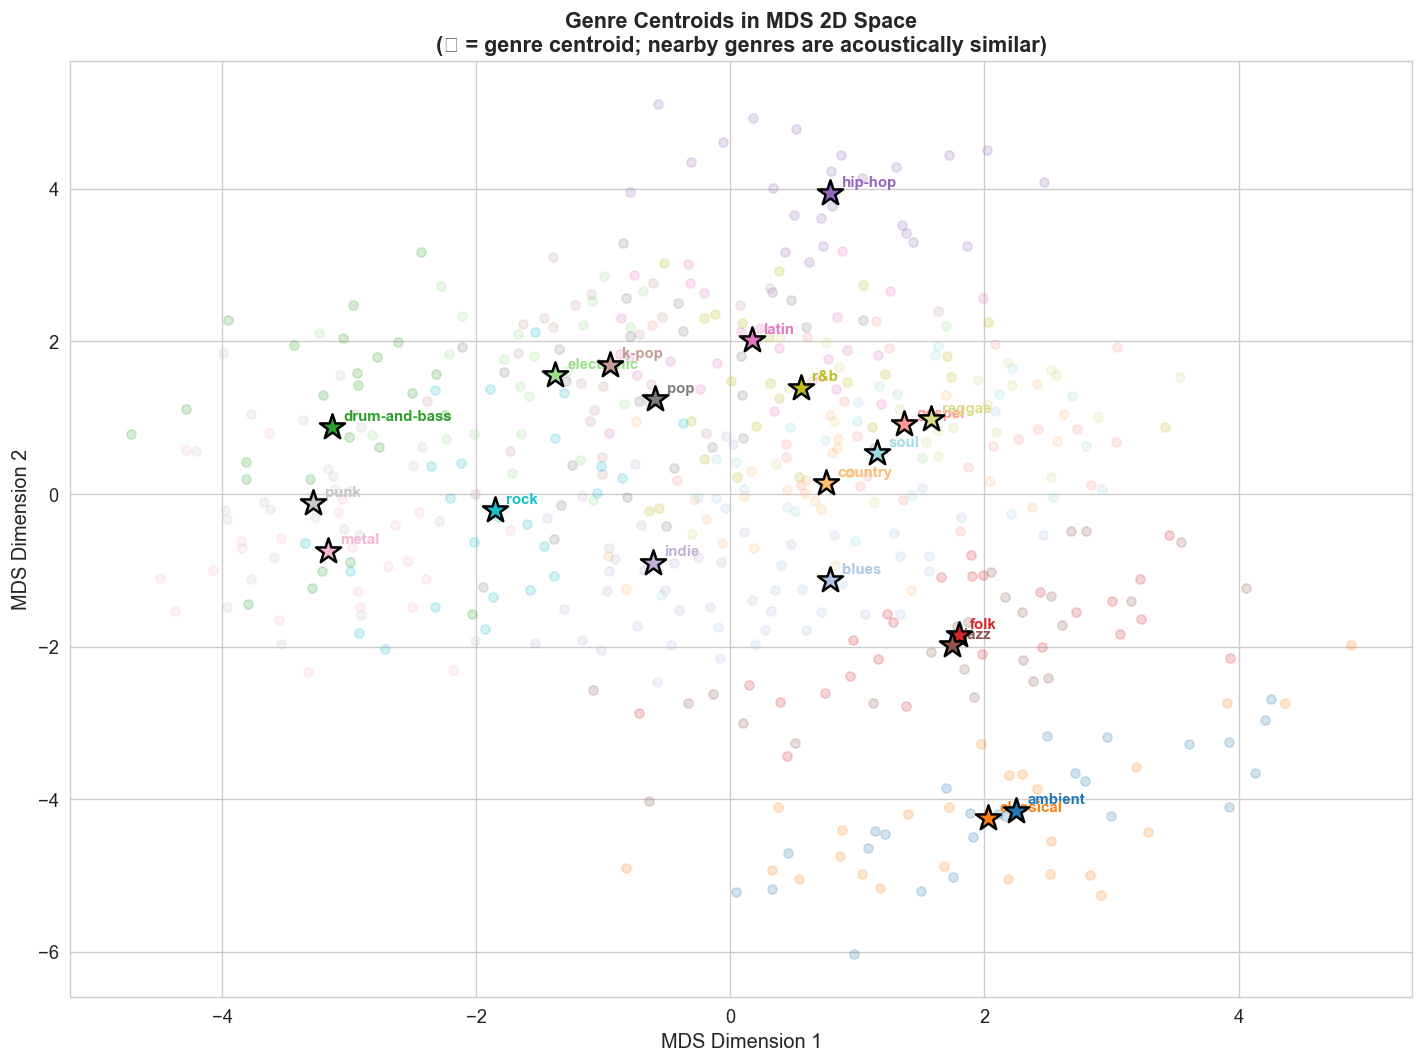

In [24]:
# Compute genre centroids in MDS 2D space
centroids = {}
for i, genre in enumerate(genres):
    mask = genre_names == genre
    centroids[genre] = X_mds_2d[mask].mean(axis=0)

centroid_arr = np.array(list(centroids.values()))
centroid_labels = list(centroids.keys())

fig, ax = plt.subplots(figsize=(12, 9))

# Plot all points (faded)
for i, genre in enumerate(genres):
    mask = genre_names == genre
    ax.scatter(X_mds_2d[mask, 0], X_mds_2d[mask, 1],
               color=cmap(i), alpha=0.2, s=30)

# Plot centroids
for i, (genre, c) in enumerate(centroids.items()):
    ax.scatter(c[0], c[1], color=cmap(i), s=250, edgecolors='black',
               linewidths=1.5, zorder=5, marker='*')
    ax.annotate(genre, (c[0], c[1]), textcoords='offset points',
                xytext=(7, 4), fontsize=9, fontweight='bold',
                color=cmap(i))

ax.set_xlabel('MDS Dimension 1', fontsize=12)
ax.set_ylabel('MDS Dimension 2', fontsize=12)
ax.set_title('Genre Centroids in MDS 2D Space\n(★ = genre centroid; nearby genres are acoustically similar)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

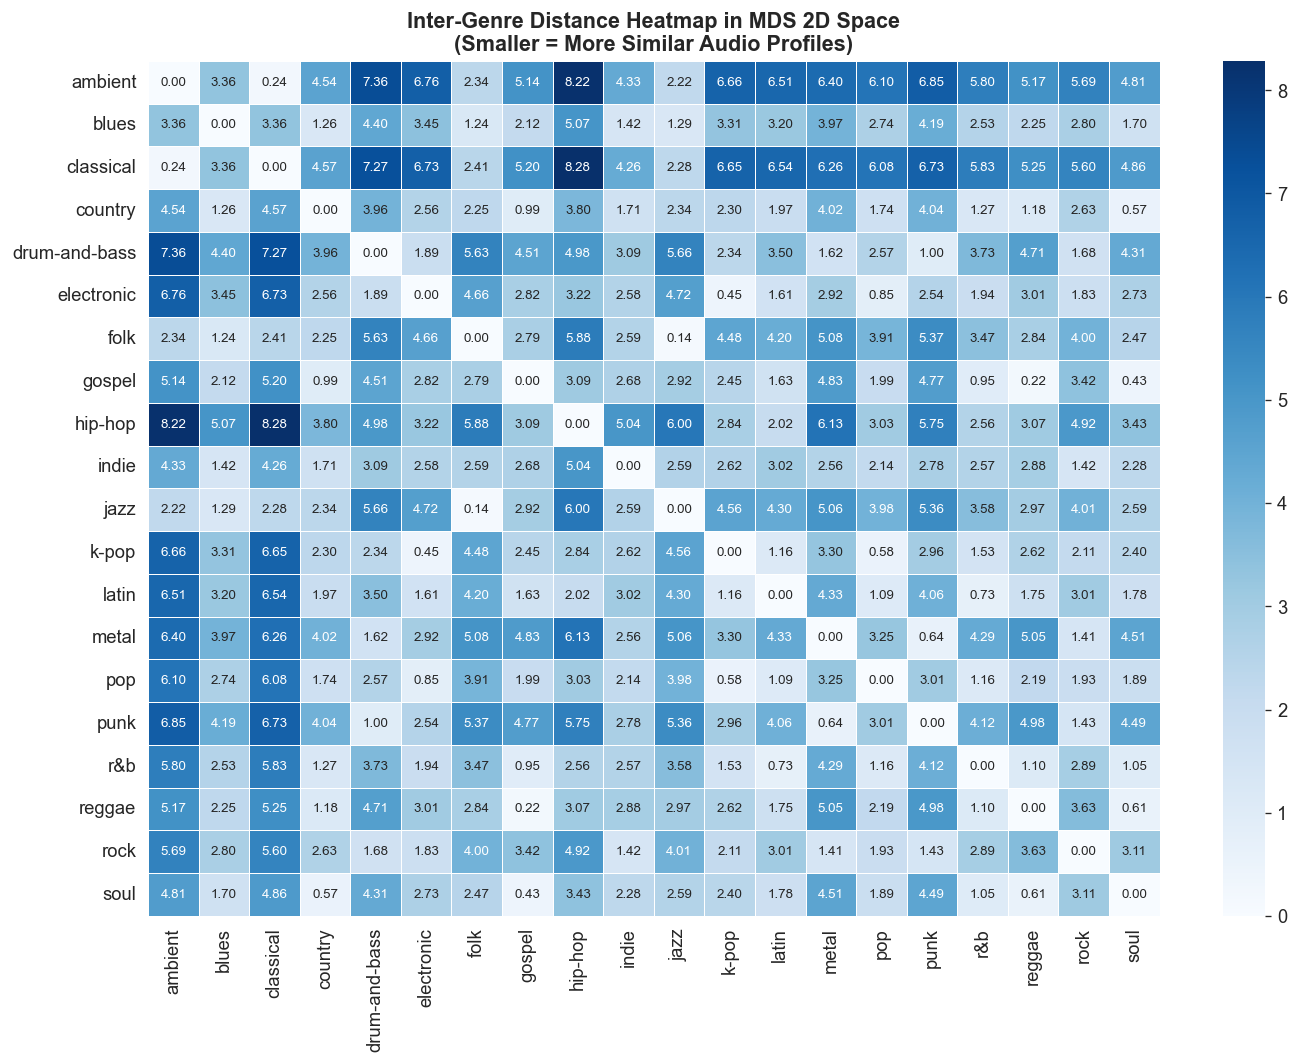

In [25]:
# Inter-genre distance heatmap (in MDS 2D space)
centroid_dist = pairwise_distances(centroid_arr)
centroid_df = pd.DataFrame(centroid_dist, index=centroid_labels, columns=centroid_labels)

plt.figure(figsize=(12, 9))
sns.heatmap(centroid_df, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Inter-Genre Distance Heatmap in MDS 2D Space\n(Smaller = More Similar Audio Profiles)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()